# 18 - Árvore Rubro Negra

### Desenhar árvore vertical

In [ ]:
# ------------------------------------------------------------
# Função para desenhar a árvore em formato de texto (ASCII)
# ------------------------------------------------------------
def desenhar_arvore_vertical(raiz, NIL):
    linhas, *_ = _desenhar_rec(raiz, NIL)  # Monta o desenho da árvore chamando função recursiva

    # Loop para imprimir cada linha do desenho
    for linha in linhas:
        print(linha)


# Função recursiva para construir o desenho ------------------------------------------
def _desenhar_rec(no, NIL):
    # Verifica se o nó é o nó sentinela NIL
    if no == NIL:
        return [" "], 1, 1, 0  # Retorna estrutura vazia

    # Verifica a cor do nós (preto/vermelho)
    if no.cor == "PRETO":
        texto = f"{no.dado}(p)"  # Formata texto do nó preto
    else:
        texto = f"{no.dado}(v)"  # Formata texto do nó vermelho

    # Verifica se é nó folha
    if no.esquerda == NIL and no.direita == NIL:
        linha = f"{texto}"      # Define linha com valor do nó
        largura = len(linha)    # Calcula largura da linha
        return [linha], largura, 1, largura // 2    # Retorna estrutura da folha

    esquerda, largura_esq, altura_esq, meio_esq = _desenhar_rec(no.esquerda, NIL)   # Desenha subárvore esquerda
    direita, largura_dir, altura_dir, meio_dir = _desenhar_rec(no.direita, NIL)     # Desenha subárvore direita

    valor = f"{texto}"          # Define valor do nó atual
    largura_valor = len(valor)  # Calcula largura do valor

    primeira_linha = " " * (meio_esq + 1) + "_" * (largura_esq - meio_esq - 1)  # Monta parte esquerda da linha
    primeira_linha += valor  # Adiciona valor do nó
    primeira_linha += "_" * meio_dir + " " * (largura_dir - meio_dir)           # Monta parte direita da linha

    segunda_linha = " " * meio_esq + "/" + " " * (largura_esq - meio_esq - 1 + largura_valor + meio_dir) + "\\"  # Conexão esquerda e direita
    segunda_linha += " " * (largura_dir - meio_dir - 1)  # Completa espaçamento

    # Se altura esquerda menor que altura direita
    if altura_esq < altura_dir:
        esquerda += [" " * largura_esq] * (altura_dir - altura_esq)     # Ajusta altura da esquerda
    # Se altura direita menor que altura esquerda
    elif altura_dir < altura_esq:
        direita += [" " * largura_dir] * (altura_esq - altura_dir)      # Ajusta altura da direita

    linhas = [primeira_linha, segunda_linha]  # Cria lista de linhas iniciais

    # Percorre linhas das subárvores
    for e, d in zip(esquerda, direita):
        linhas.append(e + " " * largura_valor + d)  # Junta esquerda + valor + direita

    # Retorna estrutura completa
    return linhas, largura_esq + largura_valor + largura_dir, max(altura_esq, altura_dir) + 2, largura_esq + largura_valor // 2

### Class e Testes

In [ ]:
# ---------------------------------------
# Class para inserção de Nó
# ---------------------------------------
class Nodo:
    def __init__(self, dado, cor="VERMELHO"):
        self.dado = dado        # armazena o valor
        self.cor = cor          # armazena a cor do nodo
        self.esquerda = None    # ponteiro para filho esquerdo
        self.direita = None     # ponteiro para filho direito
        self.pai = None         # ponteiro para o pai

# ---------------------------------------
# Class de Criaçã da Árvore Rubro Negra
# ---------------------------------------
class ArvoreRubroNegra:
    def __init__(self):
        self.NIL = Nodo(None, cor="PRETO")  # cria nodo sentinela preto
        self.raiz = self.NIL                # raiz começa apontando para NIL

    # Inserir um valor na árvore ---------------------------------------------
    def inserir(self, chave):
        novo = Nodo(chave)                      # cria novo nodo vermelho
        novo.esquerda = novo.direita = self.NIL # filhos apontam para NIL
        pai = None          # variável para guardar o pai
        atual = self.raiz   # começa pela raiz

        # percorre a árvore
        while atual != self.NIL:
            pai = atual                 # guarda o pai
            if novo.dado < atual.dado:  # se novo.dado é menor vai para esquerda
                atual = atual.esquerda  # desce para esquerda
            else:
                atual = atual.direita   # desce para direita

        novo.pai = pai  # define o pai do novo nodo

        # se árvore vazia
        if pai is None:
            self.raiz = novo        # novo nodo vira raiz
        elif novo.dado < pai.dado:  # se menor que o pai
            pai.esquerda = novo     # liga na esquerda
        else:
            pai.direita = novo  # liga na direita

        self._corrigir_insercao(novo)  # corrige propriedades da árvore

    # Balanceamento após inserir ---------------------------------------------
    def _corrigir_insercao(self, k):  #
        # enquanto pai for vermelho
        while k.pai and k.pai.cor == "VERMELHO":
            if k.pai == k.pai.pai.esquerda:     # se pai é filho esquerdo
                tio = k.pai.pai.direita         # tio é o filho direito do avô

                if tio.cor == "VERMELHO":       # caso 1: tio vermelho
                    tio.cor = "PRETO"           # tio vira preto
                    k.pai.cor = "PRETO"         # pai vira preto
                    k.pai.pai.cor = "VERMELHO"  # avô vira vermelho
                    k = k.pai.pai               # sobe para o avô
                else:
                    if k == k.pai.direita:      # caso 2: rotação esquerda
                        k = k.pai               # sobe um nível
                        self._rodar_esq(k)      # rotação esquerda

                    k.pai.cor = "PRETO"         # pai vira preto
                    k.pai.pai.cor = "VERMELHO"  # avô vira vermelho
                    self._rodar_dir(k.pai.pai)  # rotação direita

            else:  # caso simétrico
                tio = k.pai.pai.esquerda        # tio é o filho esquerdo

                # caso 1: tio vermelho
                if tio.cor == "VERMELHO":
                    tio.cor = "PRETO"           # tio vira preto
                    k.pai.cor = "PRETO"         # pai vira preto
                    k.pai.pai.cor = "VERMELHO"  # avô vira vermelho
                    k = k.pai.pai               # sobe para o avô
                else:
                    # caso 2: rotação direita
                    if k == k.pai.esquerda:
                        k = k.pai           # sobe um nível
                        self._rodar_dir(k)  # rotação direita

                    k.pai.cor = "PRETO"         # pai vira preto
                    k.pai.pai.cor = "VERMELHO"  # avô vira vermelho
                    self._rodar_esq(k.pai.pai)  # rotação esquerda

            # se chegou na raiz, para o loop
            if k == self.raiz:
                break

        self.raiz.cor = "PRETO"  # raiz sempre preta

    # Rotação à esquerda ---------------------------------------------
    def _rodar_esq(self, x):        # rotação esquerda
        y = x.direita               # y recebe filho direito
        x.direita = y.esquerda      # move subárvore
        # se existir subárvore
        if y.esquerda != self.NIL:
            y.esquerda.pai = x      # atualiza pai

        y.pai = x.pai   # liga y ao pai de x

        # se x era raiz
        if not x.pai:
            self.raiz = y           # y vira raiz
        # se x era filho esquerdo
        elif x == x.pai.esquerda:
            x.pai.esquerda = y      # y substitui x
        else:
            x.pai.direita = y  # y substitui x

        y.esquerda = x  # x vira filho esquerdo
        x.pai = y  # atualiza pai

    # Rotação à direita ---------------------------------------------
    def _rodar_dir(self, x):
        y = x.esquerda          # y recebe filho esquerdo
        x.esquerda = y.direita  # move subárvore
        # se existir subárvore
        if y.direita != self.NIL:
            y.direita.pai = x   # atualiza pai

        y.pai = x.pai   # liga y ao pai de x

        # se x era raiz
        if not x.pai:
            self.raiz = y       # y vira raiz
        # se x era filho direito
        elif x == x.pai.direita:
            x.pai.direita = y  # y substitui x
        else:
            x.pai.esquerda = y  # y substitui x

        y.direita = x       # x vira filho direito
        x.pai = y           # atualiza pai

    # Exibir a árvore ---------------------------------------------
    def exibir(self, nodo=None, prefixo="", ultimo=True):
        # se não passar nodo
        if nodo is None:
            nodo = self.raiz    # começa pela raiz

        # se não for NIL
        if nodo != self.NIL:
            print(prefixo, "- " if ultimo else "|- ", f"{nodo.dado}({nodo.cor})", sep="")   # imprime nodo
            novo_prefixo = prefixo + ("   " if ultimo else "|  ")                           # ajusta prefixo

            filhos = []  # lista de filhos
            # se tiver filho esquerdo
            if nodo.esquerda != self.NIL:
                filhos.append(nodo.esquerda)  # adiciona
            # se tiver filho direito
            if nodo.direita != self.NIL:
                filhos.append(nodo.direita)  # adiciona

            # percorre filhos
            for i, filho in enumerate(filhos):
                self.exibir(filho, novo_prefixo, i == len(filhos) - 1)  # recursão

In [ ]:
# Fluxo de Criação
# Inserir nó (vermelho)
#         ↓
# Pai é preto? → terminou
#         ↓
# Pai é vermelho
#         ↓
# Tio vermelho → troca cores
# Tio preto → rotação
#         ↓
# Raiz vira preta
## TESTANDO ------------------------------
arn = ArvoreRubroNegra()  # cria árvore
valores = [10, 20, 30, 15, 25, 5, 1]  # valores para inserir
print(f"Inserindo: {valores}\n")  # mostra valores

# percorre valores
for v in valores:
    arn.inserir(v)

print("Árvore Gerada:")
arn.exibir()

print("\n--------------------------------------------------------------------------------------------------")
print("Árvore Vertical:")
desenhar_arvore_vertical(arn.raiz, arn.NIL)  # Desenha árvore Vertical

Inserindo: [10, 20, 30, 15, 25, 5, 1]

Árvore Gerada:
- 20(PRETO)
   |- 10(VERMELHO)
   |  |- 5(PRETO)
   |  |  - 1(VERMELHO)
   |  - 15(PRETO)
   - 30(PRETO)
      - 25(VERMELHO)

--------------------------------------------------------------------------------------------------
Árvore Vertical:
            _______20(p)_______    
           /                   \   
       __10(v)__           __30(p) 
      /         \         /       \
   _5(p)      15(p)     25(v)      
  /     \                          
1(v)                               


#
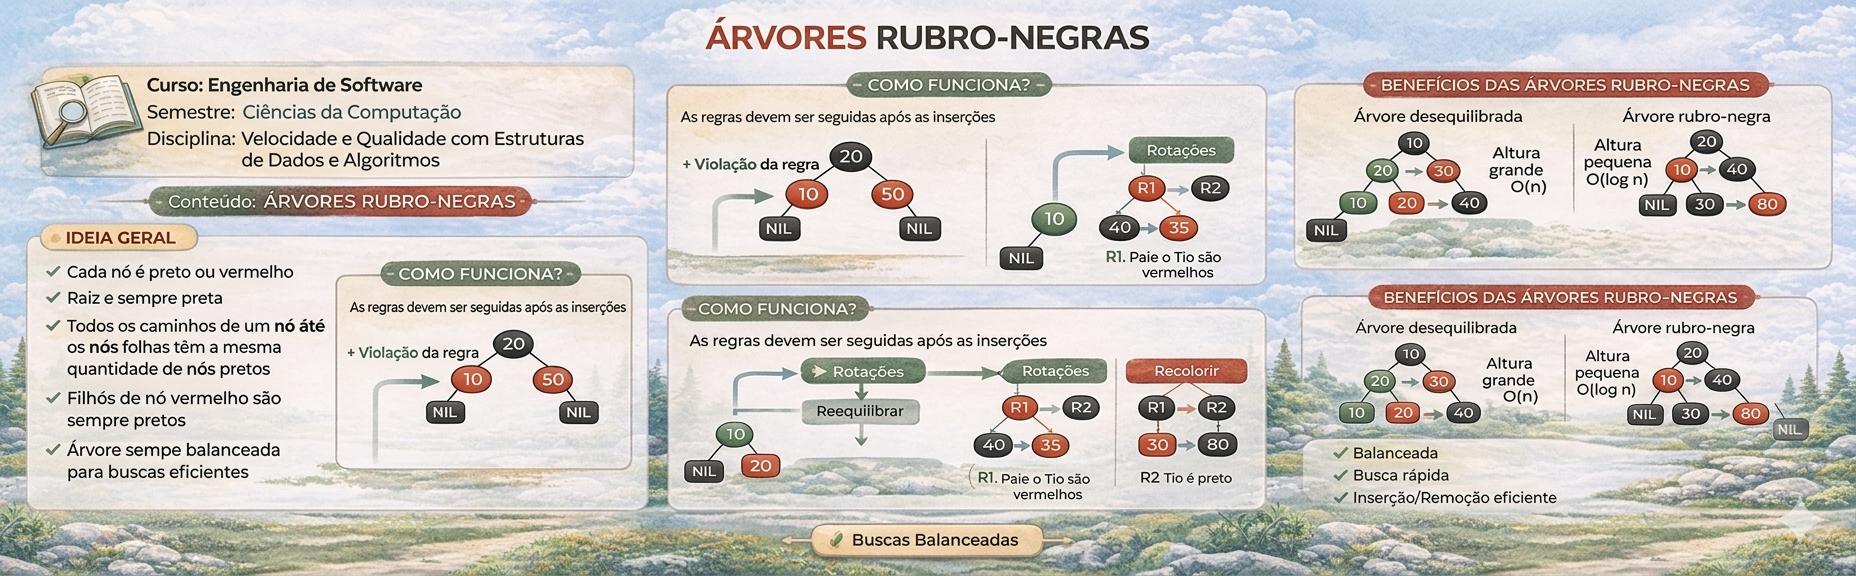